# Intervalle optimal de check-point

Sur les gros jobs, les pannes (nœud ou système) peuvent faire perdre tout le calcul depuis la dernière écriture de redémarrage. Le check-point (écriture d’états de reprise sur disque) limite la perte mais coûte du temps I/O. Ce module calcule **l’intervalle optimal entre deux check-points** qui maximise le temps de calcul utile attendu.

**N = nombre de nœuds de calcul** (pas de cœurs). Les pannes sont modélisées au niveau **nœud** (panne matérielle, réseau, etc.) ; un nœud en panne met hors service tous ses cœurs.

**Modèle :**
- Probabilité de survie sur $t_c$ avec $N$ nœuds : $P_N(t_c \mid \lambda) = e^{-\lambda N t_c}$ ($\lambda$ = taux de panne par nœud).
- Avec une durée de check-point $T_c$, la fraction du temps passée en calcul est $t_c/(t_c + T_c)$.
- On maximise $w(t_c) = \frac{t_c}{t_c + T_c}\, e^{-\lambda N t_c}$, d’où
  $$\hat{t}_c = \frac{T_c}{2}\left(\sqrt{1 + \frac{4}{\lambda N T_c}} - 1\right)$$

Toutes les durées dans l’API sont en **heures**.

## 1. Entrées

Nombre de **nœuds** de calcul, durée d’écriture d’un check-point, et taux de panne (ou MTBF en années).

In [11]:
from pathlib import Path
import sys
import cfd_perf

# Chemin vers la librairie plotting (figures soignées)
PLOTTING_PATH = str(Path("../../scripts/post/plot").resolve())
if PLOTTING_PATH not in sys.path:
    sys.path.insert(0, PLOTTING_PATH)

# Taille du job : nombre de nœuds de calcul (pas de cœurs)
n_nodes = 8

# Durée d'écriture d'un check-point (en heures ; 5 min = 5/60)
Tc_hours = 5.0 / 60.0  # 5 minutes

# Taux de panne : MTBF par nœud en années (réaliste ~15 ans pour beaucoup de clusters)
mtbf_years = 5.0
lambda_per_hour = cfd_perf.mtbf_years_to_failure_rate(mtbf_years)

print(f"Nœuds :       {n_nodes}")
print(f"Tc :          {Tc_hours * 60:.1f} min")
print(f"MTBF :        {mtbf_years} ans par nœud")
print(f"λ (par h) :  {lambda_per_hour:.2e}")

Nœuds :       8
Tc :          5.0 min
MTBF :        5.0 ans par nœud
λ (par h) :  2.28e-05


## 2. Intervalle optimal et utilisation

In [12]:
tc_opt_h = cfd_perf.optimal_interval(Tc_hours, n_nodes, lambda_per_hour)
tc_opt_min = tc_opt_h * 60

surv = cfd_perf.survival_probability(tc_opt_h, n_nodes, lambda_per_hour)
util = cfd_perf.expected_utilization(tc_opt_h, Tc_hours, n_nodes, lambda_per_hour)

print(f"Intervalle optimal :  {tc_opt_h:.2f} h  ({tc_opt_min:.0f} min)")
print(f"Prob. de survie :     {surv:.4f}")
print(f"Utilisation attendue : {util:.4f}")

Intervalle optimal :  21.33 h  (1280 min)
Prob. de survie :     0.9961
Utilisation attendue : 0.9922


## 3. Courbe w(tc) et optimum

Utilisation attendue en fonction de l’intervalle entre check-points.

/tmp/ipykernel_34830/2087665656.py:20: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


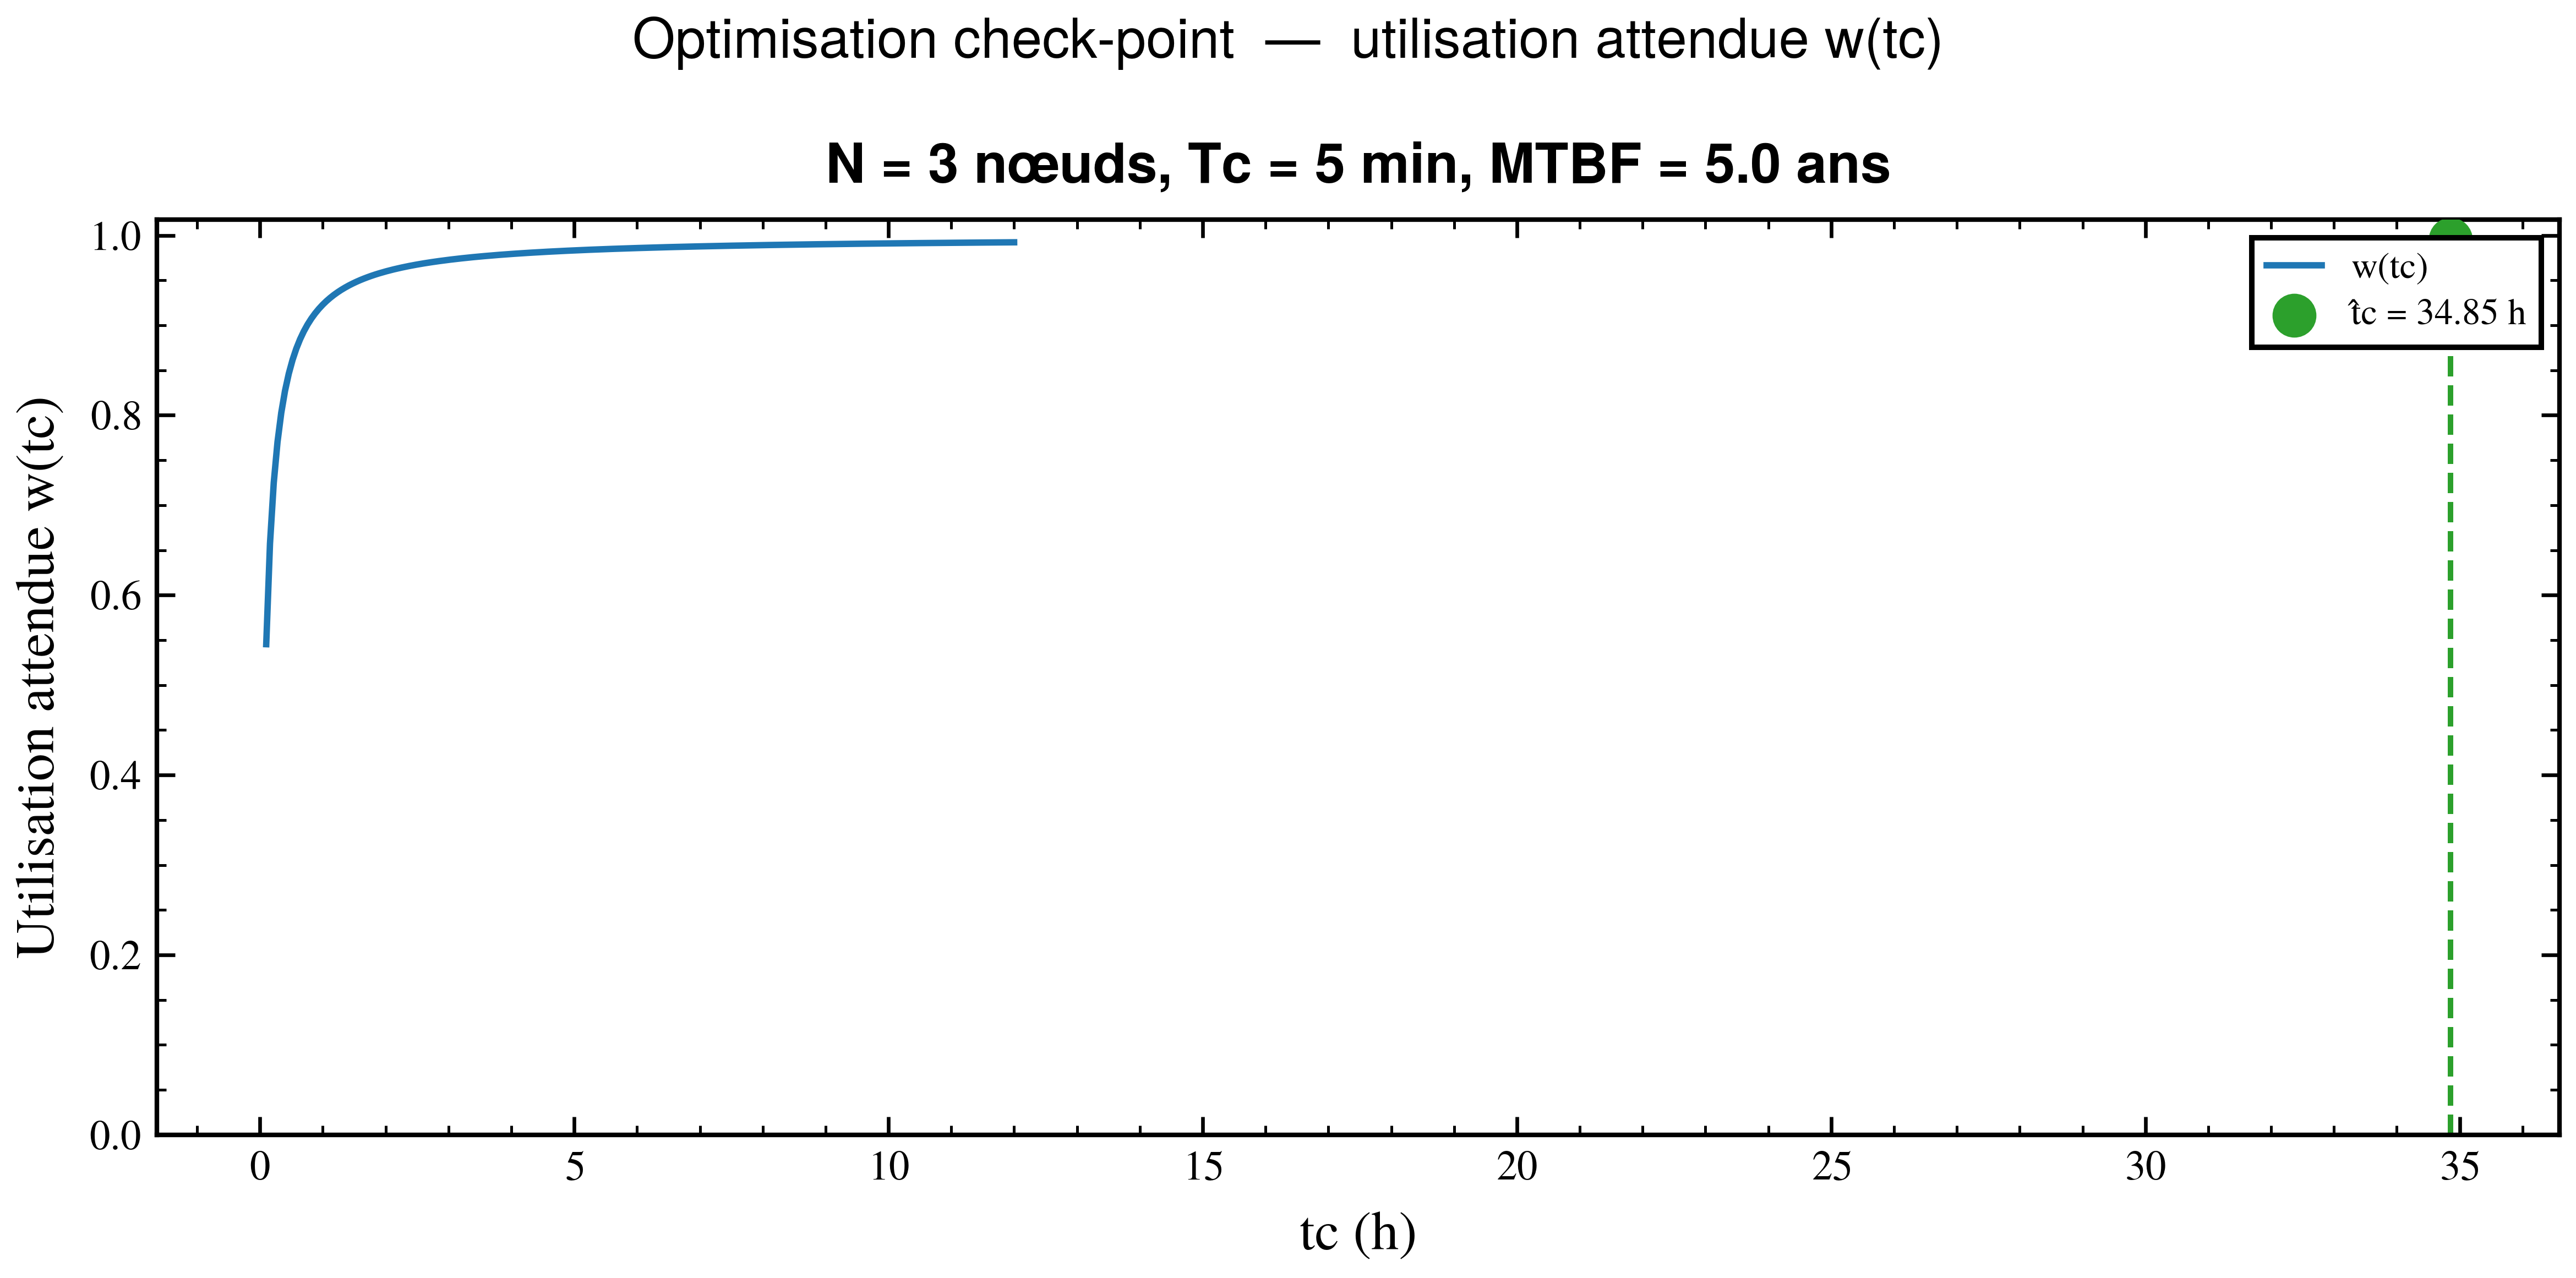

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from plotting import use_style, new_figure, plot_line, set_title, set_suptitle, apply_oldschool_axes, make_legend, add_reference_lines

tc_vals_h = np.linspace(0.1, 12, 200)
w_vals = np.array([cfd_perf.expected_utilization(tc, Tc_hours, n_nodes, lambda_per_hour) for tc in tc_vals_h])

use_style("paper")
fig, ax = new_figure(1, 1, figsize=(8, 4))
set_suptitle(fig, "Optimisation check-point  —  utilisation attendue w(tc)", fontsize=12)
set_title(ax, f"N = {n_nodes} nœuds, Tc = {Tc_hours*60:.0f} min, MTBF = {mtbf_years} ans")
plot_line(ax, tc_vals_h, w_vals, marker="", label="w(tc)")
add_reference_lines(ax, vlines=[tc_opt_h], color="C2", linewidth=1.2, linestyle="--")
ax.scatter([tc_opt_h], [util], color="C2", s=70, zorder=5, label=f"t̂c = {tc_opt_h:.2f} h")
ax.set_xlabel("tc (h)")
ax.set_ylabel("Utilisation attendue w(tc)")
ax.set_ylim(0, None)
apply_oldschool_axes(ax)
make_legend(ax, loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

## 4. Sensibilité : intervalle optimal vs nombre de nœuds

Plus le job est gros (plus de nœuds), plus l’intervalle optimal diminue (check-point plus souvent).

/tmp/ipykernel_34830/4210153678.py:13: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


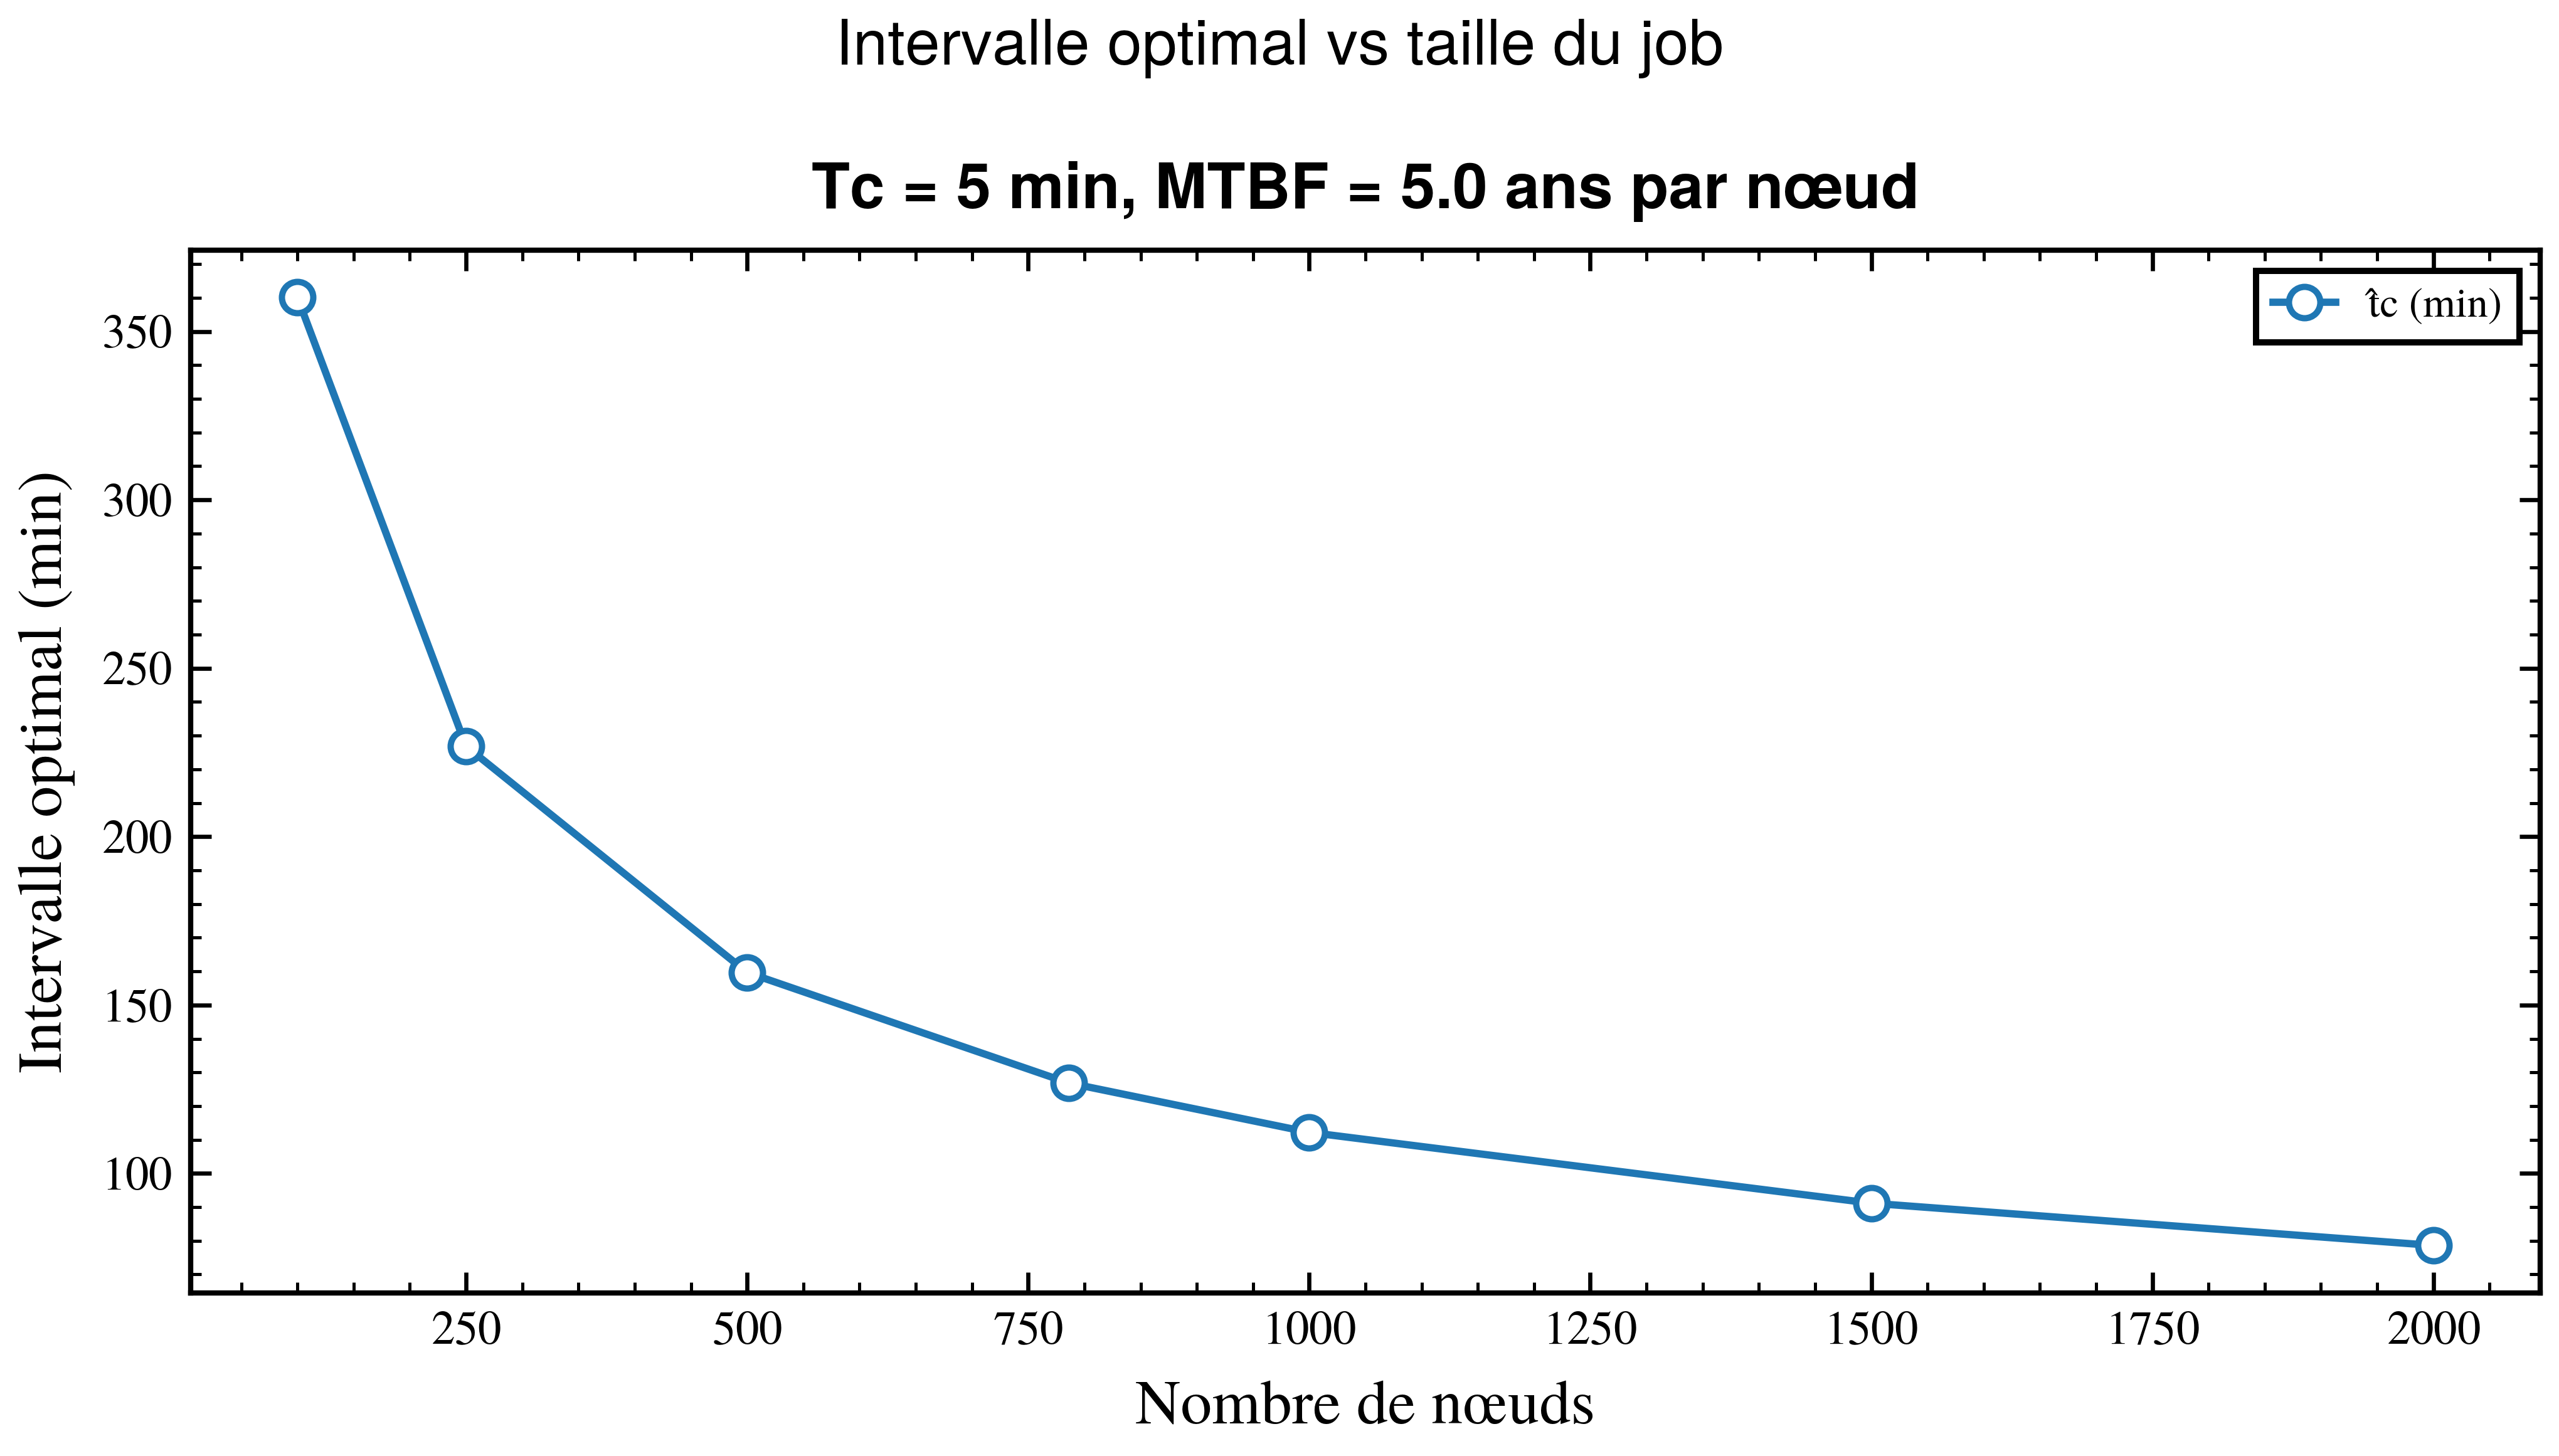

In [10]:
node_counts = [100, 250, 500, 786, 1000, 1500, 2000]
tc_opts_min = [cfd_perf.optimal_interval(Tc_hours, n, lambda_per_hour) * 60 for n in node_counts]

use_style("paper")
fig, ax = new_figure(1, 1, figsize=(7, 4))
set_suptitle(fig, "Intervalle optimal vs taille du job", fontsize=12)
set_title(ax, f"Tc = {Tc_hours*60:.0f} min, MTBF = {mtbf_years} ans par nœud")
plot_line(ax, node_counts, tc_opts_min, marker="o", markersize=6, label="t̂c (min)")
ax.set_xlabel("Nombre de nœuds")
ax.set_ylabel("Intervalle optimal (min)")
apply_oldschool_axes(ax)
make_legend(ax, loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()